# Latent capacity of both axes at equal latent dimension

The wide axis quadruples the input at the same ten-dimensional latent. This notebook compares how much of the latent each axis uses, how that relates to the dimension of its inputs, whether the two axes learn related representations and whether they segment the held-out images alike.

## Introduction

If the wide model needed more capacity it would use its latent more fully (higher effective rank, participation
ratio and TwoNN, closer to the ambient bound) while its inputs would show a higher intrinsic dimension than the
narrow inputs. Representation similarity across axes on identical pixels (CKA, kNN overlap) and the agreement of
their segmentations show whether the wide model encodes the same structure plus extra, or something different.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* Both axes are evaluated on identical pixels (same source spectra), so per-pixel comparisons are paired. The
  models of the two axes are independent; repetition $r$ of one axis is paired with repetition $r$ of the other only
  for convenience (the seeds are equal but the models are not related).
* Global $W_1$ values are not comparable across axes: the wide axis transports intensity over a longer m/z range and
  normalizes by a TIC that includes the extension. Comparisons of reconstruction therefore use the windows shared by
  both axes, where the within-window cost is renormalized and comparable.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Narrow axis $\mathcal{A}_n$ = 200-900 m/z (1273 bins); wide axis $\mathcal{A}_w$ = 100-3000 m/z (5273 bins); common
  windows = 200-300, ..., 800-900; extension windows = 100-200 and 900-3000.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "axis_comparison_latent_capacity"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
NARROW, WIDE = metadata.get('narrow_axis', 'axis-200-900'), metadata.get('wide_axis', 'axis-100-3000')
AXIS_LABELS = {axis: catalog[catalog.axis == axis].display_label.iloc[0] for axis in (NARROW, WIDE)}
AXIS_COLORS = {axis: LABEL_COLORS[AXIS_LABELS[axis]] for axis in (NARROW, WIDE)}
DATASETS = sorted(load_table(settings, 'axis_comparison_reconstruction', 'image_maps').dataset_id.unique())
print('Narrow axis:', NARROW, '| wide axis:', WIDE, '| held-out images:', DATASETS)

capacity = table('capacity')
LATENT_POPULATIONS = ['train', 'test', 'heldout_image']

Analysis: axis_comparison_latent_capacity | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Narrow axis: axis-200-900 | wide axis: axis-100-3000 | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`axis_comparison_latent_capacity` recomputes the latent statistics of both axes from stored codes with the same functions as `part_1_06`, the pairwise similarity of all models and the segmentations of `part_1_07`.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis axis_comparison_latent_capacity > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False
axis-200-900  0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Segmentations are compared for the representative models (200-900: repetition 2, 100-3000: repetition 1) and for paired repetitions.

### Notes

## Latent dimension usage against input dimension

### Methodology

#### Theoretical

Latent usage (canonicalized $U$) and input dimension are compared per axis and population.

#### Implementation

`capacity` (space `u`) and `data_geometry`.

#### Figure descriptions

One panel per statistic; x = population, colour = axis, one point per repetition. Table: input dimension per
axis and population.

axis                                      axis-100-3000  axis-200-900
metric                     population                                
effective_rank             heldout_image         1.8889        2.0125
                           test                  5.0968        4.5986
                           train                 5.1024        4.6132
participation_ratio        heldout_image         1.3605        1.4072
                           test                  3.9120        3.3982
                           train                 3.9148        3.4115
trace                      heldout_image         3.2071        3.3371
                           test                  5.9334        5.2327
                           train                 5.9088        5.1928
two_nn_intrinsic_dimension heldout_image         5.5844        5.6523
                           test                  5.2477        5.3278
                           train                 5.1033        5.4427

trace  effective_rank  participation_ratio  two_nn_intrinsic_dimension  components_for_80pct_variance  components_for_90pct_variance  components_for_95pct_variance  \
axis          population                                                                                                                                                                            
axis-200-900  train          0.0130         11.1215               6.1591                     10.1450                              6                             11                             18   
              test           0.0140         11.7182               6.6414                     10.0323                              7                             11                             18   
              heldout_image  0.0110          3.0566               1.6803                      9.7850                              2                              4                              7   
axis-100-3000 train          0.0326          3.9844               2.0526                      9.4375                              3                              5                              9   
              test           0.0334          4.1718               2.1116                      9.4861                              3                              6                             10   
              heldout_image  0.0090          3.4429               1.7942                      9.9100                              2                              5                              8   

                             components_for_99pct_variance  
axis          population                                    
axis-200-900  train                                     56  
              test                                      57  
              heldout_image                             26  
axis-100-3000 train                                     28  
              test                                      28  
              heldout_image                             33

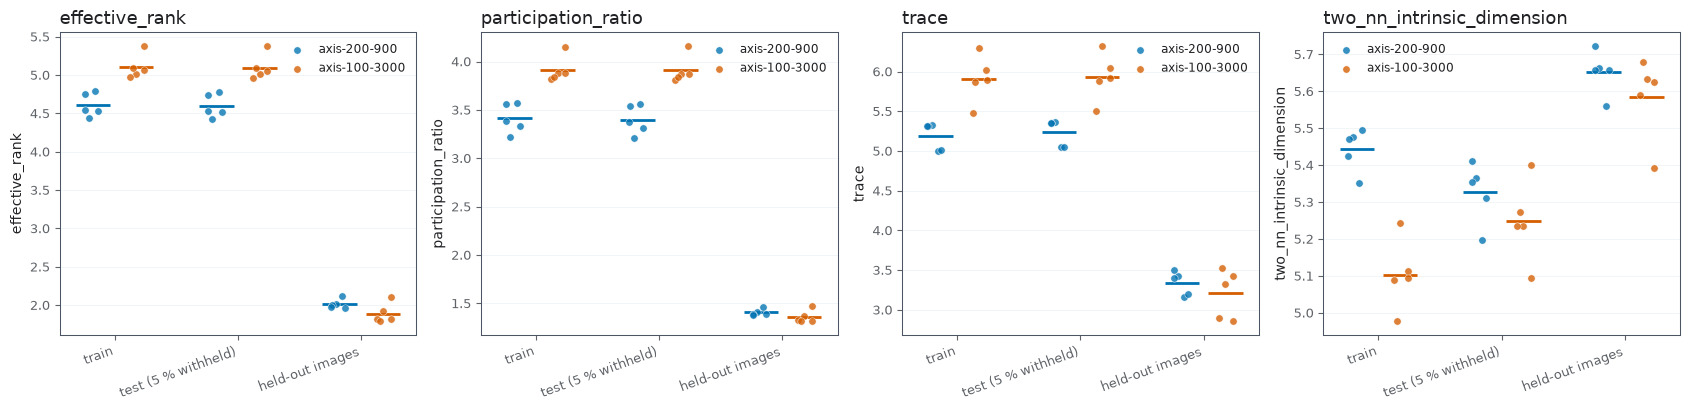

In [4]:
usage = capacity[(capacity.space == 'u') & capacity.metric.isin(['effective_rank', 'participation_ratio', 'trace', 'two_nn_intrinsic_dimension'])]
figure, axes = plt.subplots(1, 4, figsize=(17, 4.2), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['effective_rank', 'participation_ratio', 'trace', 'two_nn_intrinsic_dimension']):
    figures.repetition_points(usage[usage.metric == metric], value='value', group='population', hue='axis', order=LATENT_POPULATIONS, hue_order=[NARROW, WIDE], colors=AXIS_COLORS, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
display(usage.pivot_table(index=['metric', 'population'], columns='axis', values='value', aggfunc='mean'))
display(table('data_geometry').set_index(['axis', 'population']).drop(columns=['rows'], errors='ignore'))

### Remarks

- The wide latent has higher linear usage (effective rank 5.1 vs 4.6, trace 5.9 vs 5.2 on test) and equal TwoNN (5.2-5.3); held-out usage is equal on both axes (about 2).
- Input dimension: the wide inputs have a *lower* linear dimension (effective rank 4.0 vs 11) because the 100-200 window dominates their variance, and a similar TwoNN (9.4 vs 10).

### Notes

## Latent eigenvalue spectra of both axes

### Methodology

#### Theoretical

The share of latent variance per principal direction shows whether the wide axis spreads its codes over more directions.

#### Implementation

`eigenvalues` (space `u`), normalized per model and population.

#### Figure descriptions

x = latent component, y = share of variance; colour = axis, one line per repetition; panels = populations.

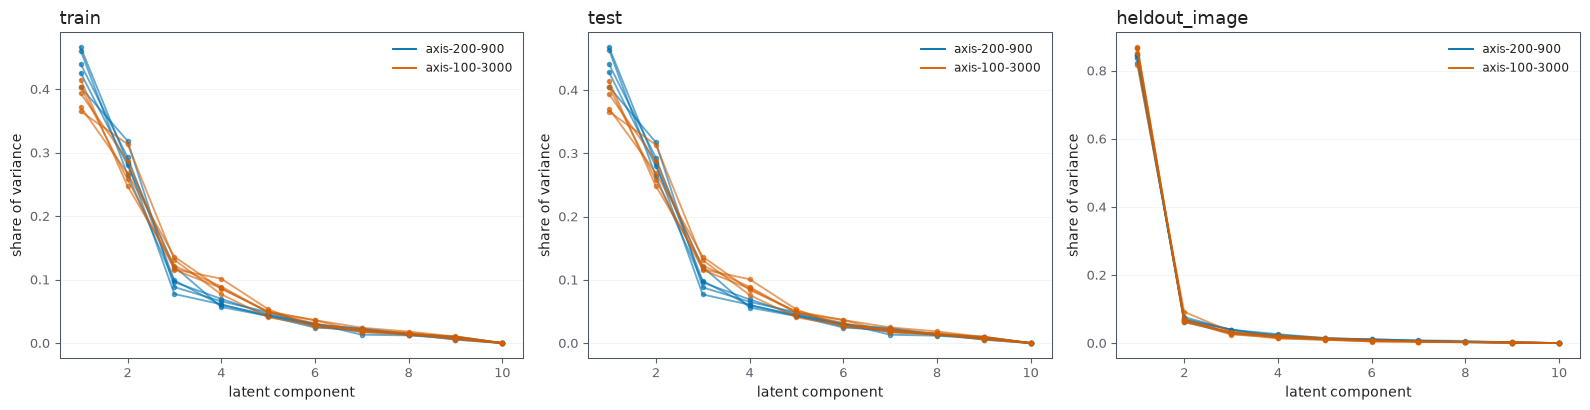

In [5]:
eigen = table('eigenvalues')
eigen = eigen[eigen.space == 'u'].copy()
eigen['share'] = eigen.value / eigen.groupby(['model_id', 'population']).value.transform('sum')
figure, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=theme.figure_dpi)
for ax, population in zip(axes, LATENT_POPULATIONS):
    figures.line_by_repetition(eigen[eigen.population == population], x='component', y='share', color_by='axis', levels=[NARROW, WIDE], colors=AXIS_COLORS, xlabel='latent component', ylabel='share of variance', title=population, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

### Notes

## Representation similarity within and across axes

### Methodology

#### Theoretical

Linear CKA, Procrustes distance and neighbourhood preservation for every pair of models on identical pixels.
Within-axis pairs give the reproducibility level; across-axis pairs are compared against it.

#### Implementation

`cross_axis_similarity` (all 45 pairs of the ten models, test and held-out samples).

#### Figure descriptions

x = pair kind, colour = population, one point per pair; panels = statistics.

linear_cka  procrustes_distance  knn_overlap  trustworthiness  continuity
pair_kind     population                                                                              
across axes   heldout_image      0.9954               0.1674       0.5473           0.9899      0.9926
              test               0.8706               0.4340       0.5699           0.9949      0.9904
within narrow heldout_image      0.9981               0.1053       0.7250           0.9986      0.9986
              test               0.9745               0.2352       0.7655           0.9990      0.9990
within wide   heldout_image      0.9965               0.1250       0.6971           0.9973      0.9981
              test               0.9672               0.2236       0.7866           0.9990      0.9991

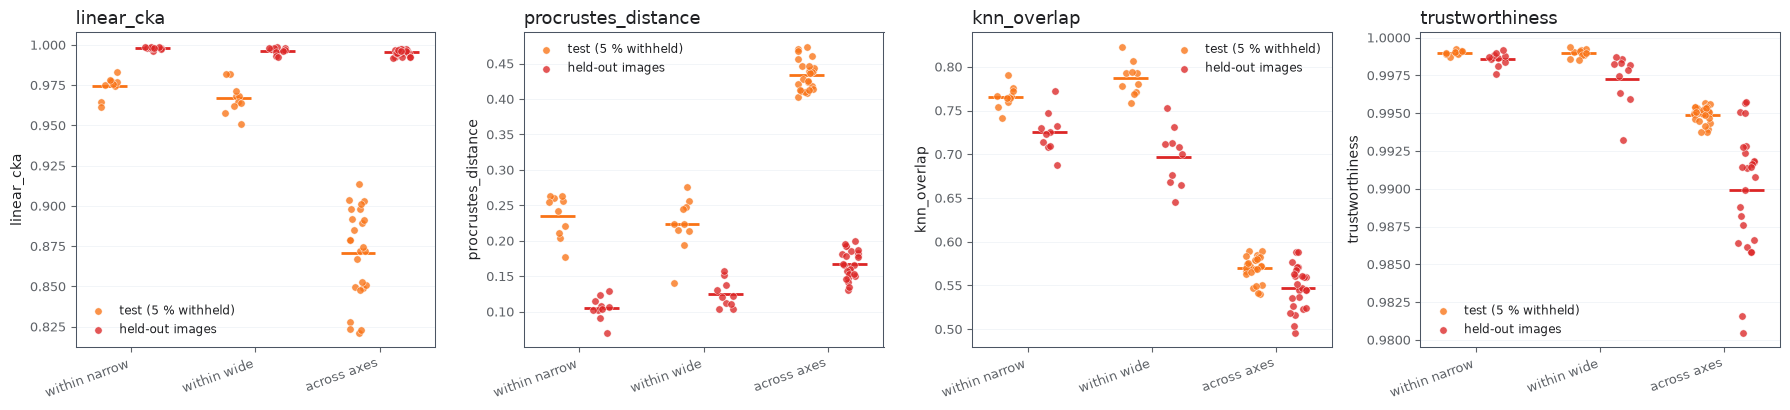

In [6]:
similarity = table('cross_axis_similarity')
similarity['pair_kind'] = np.where(similarity.pair_kind == 'across_axes', 'across axes', np.where(similarity.left_axis == NARROW, 'within narrow', 'within wide'))
figure, axes = plt.subplots(1, 4, figsize=(18, 4.2), dpi=theme.figure_dpi)
for ax, statistic in zip(axes, ['linear_cka', 'procrustes_distance', 'knn_overlap', 'trustworthiness']):
    figures.repetition_points(similarity, value=statistic, group='pair_kind', hue='population', order=['within narrow', 'within wide', 'across axes'], hue_order=['test', 'heldout_image'], colors=POPULATION_COLORS, ylabel=statistic, title=statistic, ax=ax, theme=theme)
figure.tight_layout()
display(similarity.groupby(['pair_kind', 'population'])[['linear_cka', 'procrustes_distance', 'knn_overlap', 'trustworthiness', 'continuity']].mean())

### Remarks

- Across axes linear CKA is 0.87 on test (within an axis 0.97) and 0.995 on held-out; kNN overlap 0.57 across vs 0.78 within: the axes learn related but not identical representations.

### Notes

## Segmentation agreement across axes

### Methodology

#### Theoretical

The ARI between the narrow and the wide segmentation of the same held-out pixels (same $k$) is compared with
the within-axis reproducibility of `part_1_07`, for paired repetitions and for the two representative models.
The overlap matrix of the representative partitions (wide aligned to narrow, so equal colours are matched
segments) shows which segments correspond across axes.

#### Implementation

`segmentation_agreement`, `side_by_side_segments` and `segment_contingency` (representative models, narrow selected $k$, wide labels aligned to narrow).

#### Figure descriptions

First: x = $k$, colour = comparison, one point per pair. Second: rows = images, columns = narrow and wide segmentation (same palette). Third: rows = narrow segment, columns = wide segment, colour = share of the narrow segment.

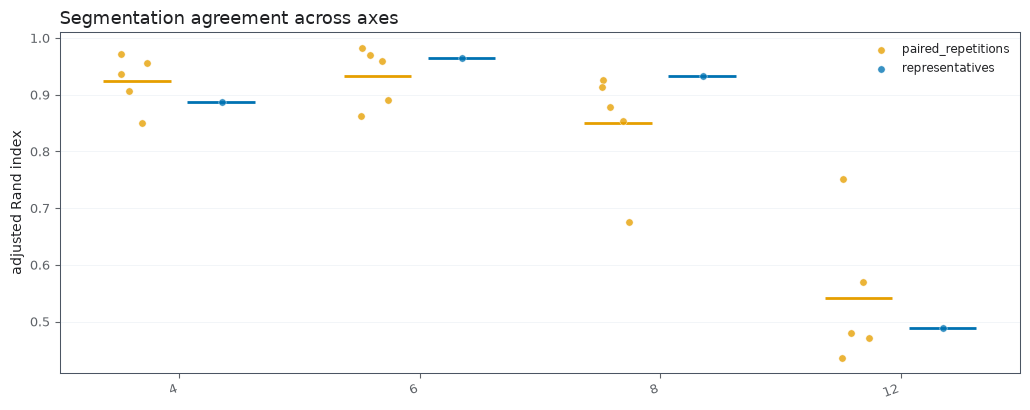

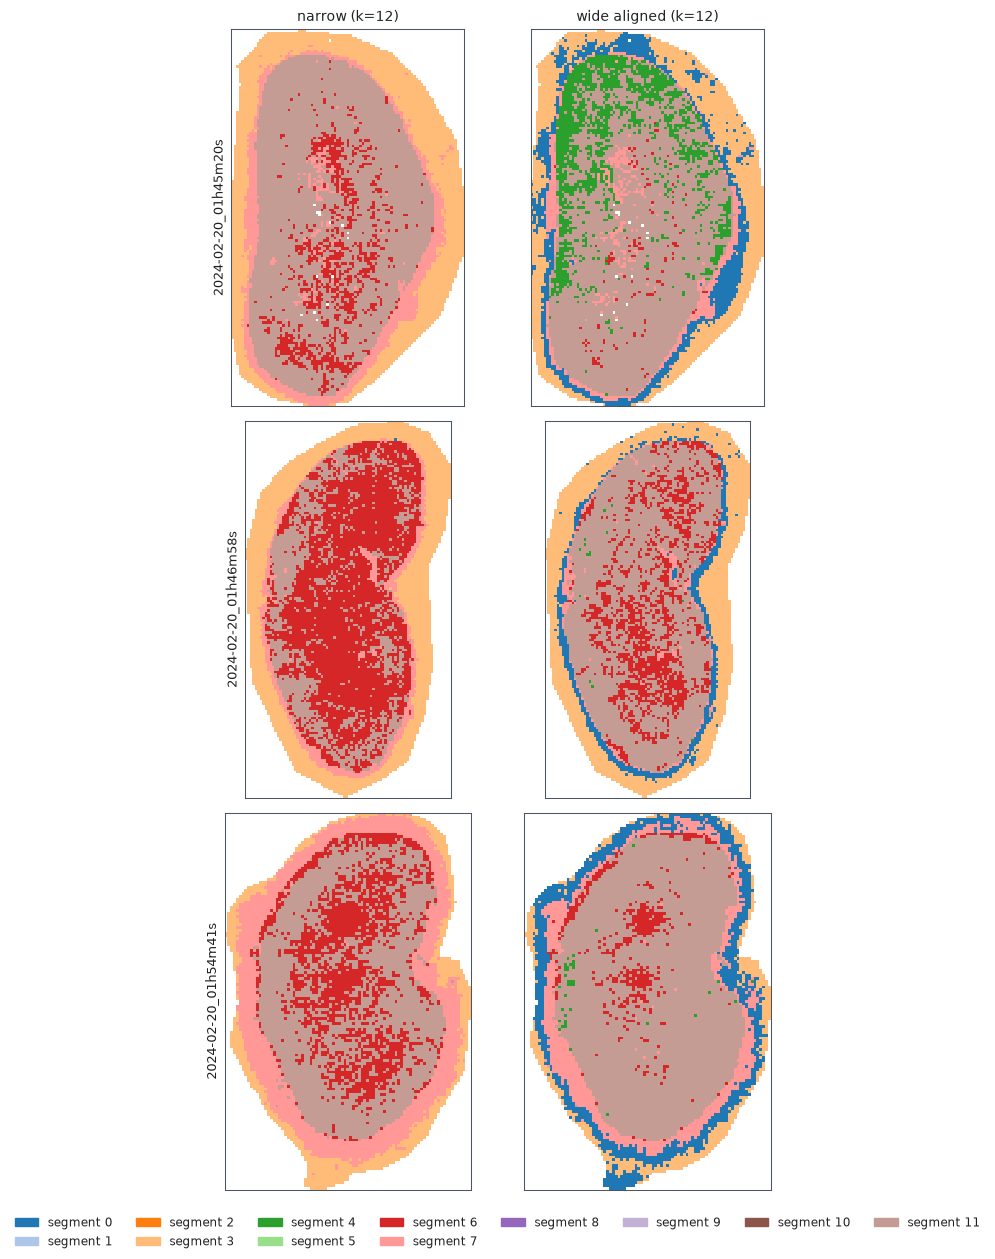

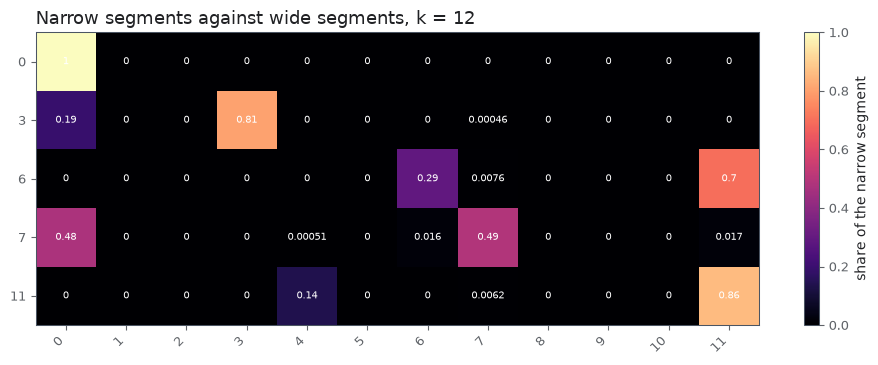

In [7]:
agreement = table('segmentation_agreement')
agreement['k'] = agreement.k.astype(str)
figures.repetition_points(agreement, value='ari', group='k', hue='comparison', order=sorted(agreement.k.unique(), key=int), hue_order=['paired_repetitions', 'representatives'], colors={'paired_repetitions': theme.model_palette[4], 'representatives': theme.model_palette[0]}, ylabel='adjusted Rand index', title='Segmentation agreement across axes', theme=theme);
k = int(metadata['selected_k'])
side = table('side_by_side_segments')
side = side[side.k == k]
figures.label_panels(side, label_columns=['segment_narrow', 'segment_wide'], column_titles=[f'narrow (k={k})', f'wide aligned (k={k})'], datasets=DATASETS, k=k, theme=theme);
contingency = table('segment_contingency')
matrix = contingency[contingency.k == k].pivot_table(index='reference_segment', columns='other_segment', values='reference_fraction')
figures.matrix_heatmap(matrix, title=f'Narrow segments against wide segments, k = {k}', colorbar_label='share of the narrow segment', annotate=True, theme=theme);

### Remarks

- ARI between axes for paired repetitions 0.92 / 0.93 / 0.85 / 0.54 at $k$ = 4 / 6 / 8 / 12; between the representative models 0.89 / 0.97 / 0.93 / 0.49.
- Matched pixel share of the representative partitions: 0.97 / 0.99 / 0.96 / 0.66: at $k$ = 6 the two axes segment the held-out images identically on 99 % of the pixels.

### Notes

## Results / Summary

### LLM

- **Observed:** the ten-dimensional latent is not saturated on either axis (TwoNN about 5 of 8 effective dimensions); the wide model uses slightly more linear directions.
- **Observed:** the representations of the two axes are related (CKA 0.87 on test) and segment the held-out images alike (ARI about 0.93 at k = 4-6).
- **Interpretation:** increasing the latent dimension for the wide axis is not indicated by latent usage; the capacity cost of the wide axis (`part_1_12`) lies in the reconstruction, which suggests decoder width or resolution rather than latent size as the relevant architectural parameter (hypothesis).

### Person